In [30]:
import xarray as xr
import numpy as np

import subprocess as sp

from geocat.comp import interp_hybrid_to_pressure

CAM case = f.e21.FWscHIST.ne30_L32_cam6_3_019_plus_CESM2.2.001.hf
<xarray.DataArray 'CLOUD' (time: 12, lev: 32, lat: 192, lon: 288)>
dask.array<concatenate, shape=(12, 32, 192, 288), dtype=float32, chunksize=(1, 32, 192, 288), chunktype=numpy.ndarray>
Coordinates:
  * lev      (lev) float64 3.643 7.595 14.36 24.61 ... 936.2 957.5 976.3 992.6
  * lon      (lon) float64 0.0 1.25 2.5 3.75 5.0 ... 355.0 356.3 357.5 358.8
  * lat      (lat) float64 -90.0 -89.06 -88.12 -87.17 ... 87.17 88.12 89.06 90.0
  * time     (time) float64 2.038e+03 2.066e+03 ... 2.342e+03 2.372e+03
Attributes:
    units:         fraction
    mdims:         1
    cell_methods:  time: mean
    long_name:     Cloud fraction
CAM case = f.e21.FWscHIST.ne30_L48_cam6_3_019_plus_CESM2.2.001.hf
<xarray.DataArray 'CLOUD' (time: 12, lev: 48, lat: 192, lon: 288)>
dask.array<concatenate, shape=(12, 48, 192, 288), dtype=float32, chunksize=(1, 48, 192, 288), chunktype=numpy.ndarray>
Coordinates:
  * lev      (lev) float64 3.063 5.2

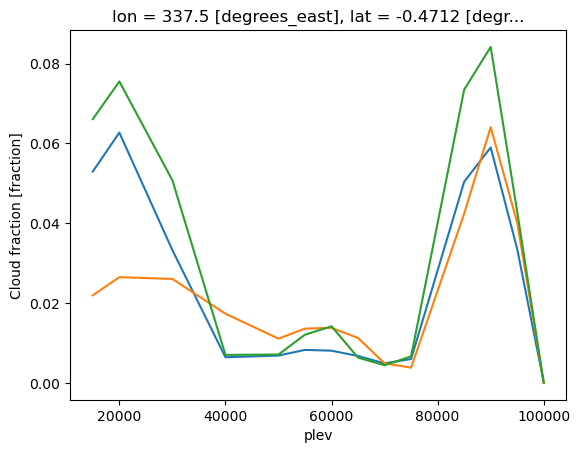

In [52]:
# Base directory
dir0 = '/glade/campaign/cgd/amp/amwg/climo/'
# CAM simulations
cases = ['f.e21.FWscHIST.ne30_L32_cam6_3_019_plus_CESM2.2.001.hf','f.e21.FWscHIST.ne30_L48_cam6_3_019_plus_CESM2.2.001.hf','f.e21.FWscHIST.ne30_L48_BL10_cam6_3_019_plus_CESM2.2.001.hf']


# New levels converted to Pascals
new_levels0 = [1000,950,900,850,750,700,650,600,550,500,400,300,200,150]
new_levels = np.array([x * 100 for x in new_levels0])


ncases = len(cases)


## Loop over cases

for icase,case in enumerate(cases): # Pick out case name and case index

    print('CAM case =', case)

    # Read in files amnd split out into a list.
    files_stub = dir0+case+'/0.9x1.25/'+case+'_??_climo.nc'
    files_case = sp.getoutput('ls '+files_stub).split()

    # Load data
    ds_in = xr.open_mfdataset(files_case,parallel=True,engine='netcdf4',decode_times=False)
    da_in = ds_in['CLOUD']

    print(da_in)
    
    # Interpolate to levels
    da_in = interp_hybrid_to_pressure(da_in,
                      ds_in['PS'],
                      hyam=ds_in['hyam'],
                      hybm=ds_in['hybm'],
                      p0=100000,
                      new_levels=new_levels,
                      method='log')

   
    
# Swap variable name
#    da_in = da_in.rename({'plev': 'lev'})

    da_in.isel(lat=95,lon=270,time=6).plot()
    
    
